# Complex Numbers — Lecture 1
## Introduction · Iota ($i$) and Its Powers · Standard Form · Algebra of Complex Numbers

**Source:** [Complex Numbers 01 | Introduction to Complex Numbers | Class 11 | JEE](https://www.youtube.com/watch?v=GVy7jdrO6pQ&list=PLF_7kfnwLFCFWA-D3XAPqcyB1z68dbgUg&index=1), Physics Wallah (Class 11), about 59 min

**Prerequisite:** quadratics and the real number system. The trigonometry lectures help for the "why it's useful" part.

### What this lecture covers
1. **History.** Why $x^2 + 1 = 0$ forced mathematicians to enlarge the number system
2. **Iota** $i = \sqrt{-1}$ (Euler, 1748) and the idea of "meaningless but not useless"
3. The number-system ladder $\mathbb{N} \subset \mathbb{W} \subset \mathbb{Z} \subset \mathbb{Q} \subset \mathbb{R} \subset \mathbb{C}$
4. **Standard (algebraic) form** $z = a + ib$, with $\operatorname{Re}(z)$ and $\operatorname{Im}(z)$
5. **Powers of $i$**: the 4-cycle, $\frac1i = -i$, and why any four consecutive powers add to $0$
6. Questions: a ratio of high powers of $i$, and $(1 + i)^{200} = x + iy$
7. **Purely real, purely imaginary, zero, and imaginary** complex numbers
8. **Algebra**: addition, subtraction, multiplication, division, scalar multiplication
9. **Equality of complex numbers**, with a question that uses it

> The lecturer's motto for this chapter: *"Not everything about it has to have a meaning, but everything about it will be useful."*

Sections marked *(extra)* go beyond what was said in the lecture. They mostly preview the geometry the lecturer promised for later lectures.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.patches import Ellipse
from IPython.display import HTML

# Same look as the trigonometry lectures
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": INK2, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
    "animation.embed_limit": 30,
})
rng = np.random.default_rng(1)

def argand(ax, lim=2.5, ticks=1):
    # Draw the complex plane: real axis horizontal, imaginary axis vertical
    ax.axhline(0, color=INK2, lw=1); ax.axvline(0, color=INK2, lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    t = np.arange(ticks, lim, ticks); t = np.r_[-t[::-1], 0, t]
    ax.set_xticks(t); ax.set_yticks(t, ["0" if v == 0 else "i" if v == 1 else "−i" if v == -1 else f"{v:g}i".replace("-", "−") for v in t])
    ax.set_xlabel("Re"); ax.set_ylabel("Im")

def arrow(ax, z0, z1, color, lw=2):
    z0, z1 = complex(z0), complex(z1)
    ax.annotate("", (z1.real, z1.imag), (z0.real, z0.imag),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, mutation_scale=14, shrinkA=0, shrinkB=0))
print("ready")

ready


---
## 1. Why New Numbers? A Little History

**Mahavira** (9th century), in his book ***Ganita Sara Sangraha***, was the first to write down that the equation
$$x^2 + 1 = 0$$
has **no solution**: no $x$ "on this planet" makes the left side zero. The reason is that $x^2 \ge 0$ for every real $x$, so $x^2 + 1 \ge 1$.

Later mathematicians reading this asked: *is our number system too small?* Other equations had the same problem, for example
$$x^2 + 4 = 0, \qquad x^2 + 2x + 2 = 0$$
In the old days such questions were simply called "unsolvable". Today we say more precisely that they have **no real solution**. To solve them, the number system had to be **extended** with new numbers "from another planet". These are the **complex numbers**.

*(The lecture's second example was spoken as $x^2 + 2x + 1 = 0$, but that one has the real root $x = -1$. Any quadratic with negative discriminant, like $x^2 + 2x + 2$, makes the intended point.)*

### Picture: "no real root" means the parabola never touches the $x$-axis

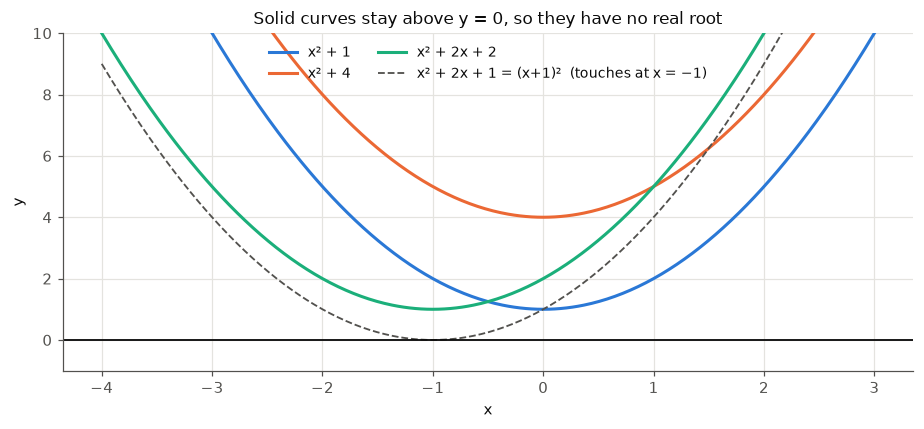

In [2]:
x = np.linspace(-4, 3, 400)
fig, ax = plt.subplots(figsize=(8.5, 4))
for f, lab, c in [(x**2 + 1, "x² + 1", BLUE), (x**2 + 4, "x² + 4", ORANGE), (x**2 + 2*x + 2, "x² + 2x + 2", AQUA)]:
    ax.plot(x, f, color=c, lw=2, label=lab)
ax.plot(x, x**2 + 2*x + 1, color=INK2, lw=1.2, ls="--", label="x² + 2x + 1 = (x+1)²  (touches at x = −1)")
ax.axhline(0, color=INK, lw=1.2)
ax.set_ylim(-1, 10); ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(frameon=False, fontsize=9, loc="upper center", ncol=2)
ax.set_title("Solid curves stay above y = 0, so they have no real root", fontsize=11)
plt.tight_layout(); plt.show()

---
## 2. Iota: $i = \sqrt{-1}$

In **1748**, **Euler** pointed out that $x^2 + 1 = 0$ means
$$x^2 = -1 \;\Longrightarrow\; x = \pm\sqrt{-1}$$
$\sqrt{-1}$ is not a real number, so he gave it a new name: **iota**, written $i$:
$$\boxed{i = \sqrt{-1}}$$

**Why the letter $i$?** It is the first letter of ***imaginary***. It is also the Greek letter *iota* ($\iota$), and the English $i$ comes from it.

So now $x^2 + 1 = 0$ **is** solvable, just not with real numbers:
$$x = i \quad\text{or}\quad x = -i$$

### "Meaningless" is not "useless"
Students ask what $i$ *really means*. The lecturer's answer: it has no real-world meaning, but **meaningless and useless are two different words**. Even rubbish can be recycled into something good. With $i$ you can:
- prove trigonometric identities such as $\sin(A - B) = \sin A\cos B - \cos A\sin B$ (shown later in the chapter),
- solve many problems in algebra, geometry and calculus.

In [3]:
# Python already knows about i. It writes it as j, the engineering convention
i = 1j
print("i      =", i)
print("i²     =", i**2)
print("roots of x² + 1:", np.roots([1, 0, 1]))
print("roots of x² + 4:", np.roots([1, 0, 4]))

i      = 1j
i²     = (-1+0j)
roots of x² + 1: [-0.+1.j  0.-1.j]
roots of x² + 4: [-0.+2.j  0.-2.j]


---
## 3. Building Complex Numbers and the Number-System Ladder

$i$ is the **smallest building block** of complex numbers. Every number you can build by combining $i$ with real numbers is a complex number:
$$i,\quad 2i,\quad -i,\quad -\sqrt3\,i,\quad 5 + 4i,\quad -2 - 3i,\quad \dots$$
Adding two of them gives another one ($i + 2i = 3i$), and so does adding a real number to an imaginary one ($5 + 4i$).

**Complex numbers = real numbers + imaginary numbers, mixed together.** The set of all complex numbers is written $\mathbb{C}$.

### How the number system grew
| Step | New numbers | Why they were needed |
|---|---|---|
| Natural numbers $\mathbb{N}$ | $1, 2, 3, \dots$ | counting |
| Whole numbers $\mathbb{W}$ | $0$ | **India gave the world zero** |
| Integers $\mathbb{Z}$ | $-1, -2, \dots$ | if one direction is positive, the other is negative |
| Rationals $\mathbb{Q}$ | $\frac12, \frac34, \dots$ | sharing: half a roti |
| Reals $\mathbb{R}$ | $\sqrt2, \pi, \dots$ (irrationals) | e.g. the area of a circle, $\pi r^2$ |
| Complex $\mathbb{C}$ | $i, 3 + 2i, \dots$ | to solve $x^2 + 1 = 0$ |

$$\boxed{\mathbb{N} \subset \mathbb{W} \subset \mathbb{Z} \subset \mathbb{Q} \subset \mathbb{R} \subset \mathbb{C}}$$

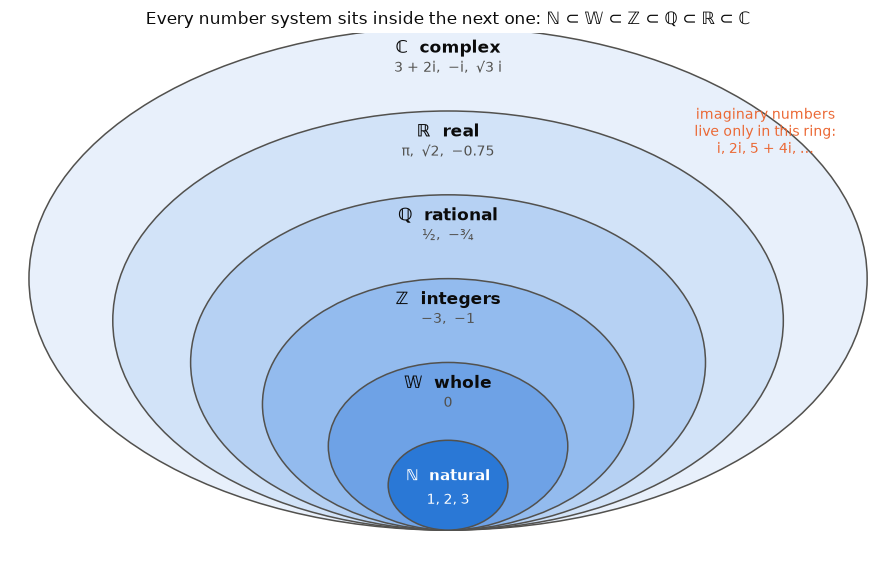

In [4]:
layers = [("ℂ  complex", "3 + 2i,  −i,  √3 i", 7.0, 4.2, "#e8f0fb"),
          ("ℝ  real", "π,  √2,  −0.75", 5.6, 3.5, "#d2e3f8"),
          ("ℚ  rational", "½,  −¾", 4.3, 2.8, "#b6d1f3"),
          ("ℤ  integers", "−3,  −1", 3.1, 2.1, "#93bbee"),
          ("𝕎  whole", "0", 2.0, 1.4, "#6ea2e6"),
          ("ℕ  natural", "1, 2, 3", 1.0, 0.75, BLUE)]
fig, ax = plt.subplots(figsize=(9, 5.4)); ax.axis("off")
for k, (name, ex, w, h, col) in enumerate(layers):
    cy = -4.2 + h  # all ellipses share the same bottom, so the labels stack above each other
    ax.add_patch(Ellipse((0, cy), 2*w, 2*h, fc=col, ec=INK2, lw=1))
    if k < 5:
        top = cy + h - 0.35
        ax.text(0, top, name, ha="center", va="center", fontsize=11, weight="bold", color=INK)
        ax.text(0, top - 0.33, ex, ha="center", va="center", fontsize=9, color=INK2)
    else:
        ax.text(0, cy + 0.15, name, ha="center", va="center", fontsize=10, weight="bold", color="white")
        ax.text(0, cy - 0.25, ex, ha="center", va="center", fontsize=9, color="white")
ax.text(5.3, 2.1, "imaginary numbers\nlive only in this ring:\ni, 2i, 5 + 4i, …", fontsize=9, color=ORANGE, ha="center")
ax.set_xlim(-7.3, 7.3); ax.set_ylim(-4.9, 4.1); ax.set_aspect("equal")
ax.set_title("Every number system sits inside the next one: ℕ ⊂ 𝕎 ⊂ ℤ ⊂ ℚ ⊂ ℝ ⊂ ℂ", fontsize=11)
plt.tight_layout(); plt.show()

---
## 4. Standard (Algebraic) Form: $z = a + ib$

In this chapter a complex number is usually called $z$ (just as a real number is usually called $x$), and several of them $z_1, z_2, \dots$

Every complex number is made of **two parts**:
$$z = \underbrace{a}_{\text{real part}} + i\,\underbrace{b}_{\text{imaginary part}}, \qquad a, b \in \mathbb{R}$$
$$\operatorname{Re}(z) = a, \qquad \operatorname{Im}(z) = b$$

Writing $z$ as $a + ib$ is called the **standard (algebraic) representation** of a complex number.

> **Common mistake:** the imaginary part is $b$, **not** $ib$. It is the real number written next to $i$.

**Every** complex number has both parts, even if one of them is $0$:
| $z$ | written as $a + ib$ | $\operatorname{Re}(z)$ | $\operatorname{Im}(z)$ |
|---|---|---|---|
| $5 + 4i$ | $5 + 4i$ | $5$ | $4$ |
| $i$ | $0 + 1\,i$ | $0$ | $1$ |
| $5$ | $5 + 0\,i$ | $5$ | $0$ |

So $5$ is a real number, **and it is also a complex number**. Adding $0$ to anything changes nothing.

**Key fact:** whatever you do to complex numbers (add, multiply, divide, take powers, roots, logs or sines), the simplified answer can always be written as **real + i · real**.

### Picture *(extra)*: $a + ib$ as a point
Plotting $\operatorname{Re}$ horizontally and $\operatorname{Im}$ vertically turns each complex number into a point. This is the **complex (Argand) plane**. The lecturer promised the geometric meaning later. Here's a preview so the ideas that follow have something to look at.

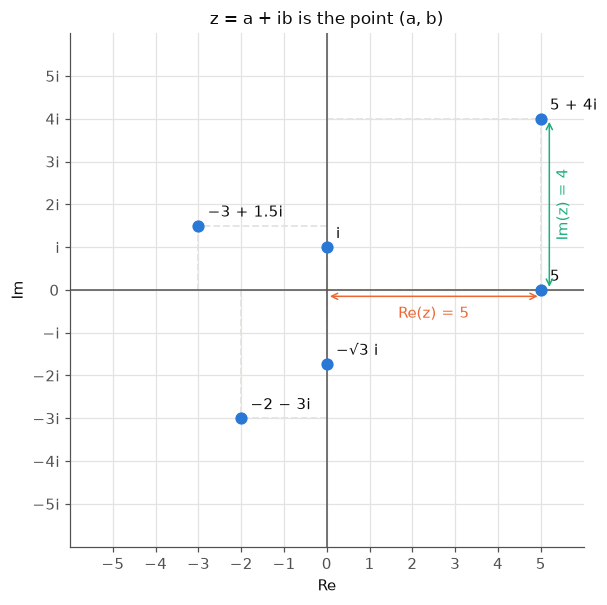

In [5]:
pts = {"5 + 4i": 5+4j, "i": 1j, "5": 5+0j, "−2 − 3i": -2-3j, "−√3 i": -np.sqrt(3)*1j, "−3 + 1.5i": -3+1.5j}
fig, ax = plt.subplots(figsize=(6.2, 5.6)); argand(ax, lim=6)
for lab, z in pts.items():
    ax.plot([z.real, z.real], [0, z.imag], color=GRID, lw=1.2, ls="--", zorder=1)
    ax.plot([0, z.real], [z.imag, z.imag], color=GRID, lw=1.2, ls="--", zorder=1)
    ax.plot(z.real, z.imag, "o", color=BLUE, ms=7, zorder=3)
    ax.annotate(lab, (z.real, z.imag), xytext=(6, 6), textcoords="offset points", fontsize=10)
z = 5+4j
ax.annotate("", (5, -0.15), (0, -0.15), arrowprops=dict(arrowstyle="<->", color=ORANGE))
ax.text(2.5, -0.65, "Re(z) = 5", color=ORANGE, ha="center")
ax.annotate("", (5.2, 4), (5.2, 0), arrowprops=dict(arrowstyle="<->", color=AQUA))
ax.text(5.35, 2, "Im(z) = 4", color=AQUA, rotation=90, va="center")
ax.set_title("z = a + ib is the point (a, b)", fontsize=11)
plt.tight_layout(); plt.show()

---
## 5. Powers of $i$

Start from $i^2 = -1$ and keep multiplying by $i$:
$$i^1 = i, \qquad i^2 = -1, \qquad i^3 = i^2\cdot i = -i, \qquad i^4 = (i^2)^2 = 1$$
and since $i^2 = -1$ means $i\cdot i = -1$, dividing by $i$ gives
$$\frac1i = -i$$

The lecturer's **five facts to know "even if woken up at midnight"**:
$$\boxed{i = \sqrt{-1},\quad i^2 = -1,\quad i^3 = -i,\quad i^4 = 1,\quad \frac1i = -i}$$

After $i^4 = 1$ the pattern **repeats every 4**: $i^5 = i,\ i^6 = -1,\ \dots$ So to find $i^n$, take the remainder of $n$ when divided by $4$:
$$i^{4k} = 1,\quad i^{4k+1} = i,\quad i^{4k+2} = -1,\quad i^{4k+3} = -i$$

### Sum of four consecutive powers is zero
$$i + i^2 + i^3 + i^4 = i - 1 - i + 1 = 0$$
More generally, for any integer $n$:
$$\boxed{i^n + i^{n+1} + i^{n+2} + i^{n+3} = i^n\left(1 + i + i^2 + i^3\right) = i^n \cdot 0 = 0}$$
For example, $i^{15} + i^{16} + i^{17} + i^{18} = 0$.

In [6]:
cycle = ["1", "i", "−1", "−i"]
for n in range(0, 9):
    print(f"i^{n} = {cycle[n % 4]:>3}      n mod 4 = {n % 4}      (Python: {np.round(1j**n, 12) + 0})")
print("1/i =", 1/1j)
for n in [1, 15, 2026, -7]:
    s = sum((1j)**(n + k) for k in range(4))
    print(f"i^{n} + i^{n+1} + i^{n+2} + i^{n+3} = {abs(s):.1e}  (≈ 0)")

i^0 =   1      n mod 4 = 0      (Python: (1+0j))
i^1 =   i      n mod 4 = 1      (Python: 1j)
i^2 =  −1      n mod 4 = 2      (Python: (-1+0j))
i^3 =  −i      n mod 4 = 3      (Python: -1j)
i^4 =   1      n mod 4 = 0      (Python: (1+0j))
i^5 =   i      n mod 4 = 1      (Python: 1j)
i^6 =  −1      n mod 4 = 2      (Python: (-1+0j))
i^7 =  −i      n mod 4 = 3      (Python: -1j)
i^8 =   1      n mod 4 = 0      (Python: (1+0j))
1/i = -1j
i^1 + i^2 + i^3 + i^4 = 0.0e+00  (≈ 0)
i^15 + i^16 + i^17 + i^18 = 0.0e+00  (≈ 0)
i^2026 + i^2027 + i^2028 + i^2029 = 1.8e-13  (≈ 0)
i^-7 + i^-6 + i^-5 + i^-4 = 0.0e+00  (≈ 0)


### Animation *(extra)*: multiplying by $i$ is a quarter-turn
Why does the cycle have length 4? In the complex plane, **multiplying by $i$ rotates a point by $90^\circ$ anticlockwise** about the origin. Four quarter-turns make a full turn, so $i^4 = 1$.

Check it on $z = a + ib$: $\;i\cdot z = ia + i^2 b = -b + ia$. The point $(a, b)$ moves to $(-b, a)$, which is exactly a $90^\circ$ rotation.

In [7]:
labels = ["1", "i", "−1", "−i", "1"]
fig, ax = plt.subplots(figsize=(5.4, 5.4), dpi=72); argand(ax, lim=1.6)
th = np.linspace(0, 2*np.pi, 200); ax.plot(np.cos(th), np.sin(th), color=GRID, lw=1.5)
for k in range(4):
    p = 1j**k
    ax.plot(p.real, p.imag, "o", color=INK2, ms=5)
    ax.annotate(f"$i^{k}$ = {labels[k]}", (p.real, p.imag), xytext=(10*np.sign(p.real + .01*p.imag) if p.real else 6,
                10 if p.imag >= 0 else -16), textcoords="offset points", fontsize=10, color=INK2)
vec, = ax.plot([], [], color=BLUE, lw=3); dot, = ax.plot([], [], "o", color=BLUE, ms=9)
trail, = ax.plot([], [], color=ORANGE, lw=2)
title = ax.set_title("", fontsize=11)
steps, per = 4, 12
frames = steps*per + 8
def update(f):
    t = min(f/per, steps)
    z = np.exp(1j*np.pi/2*t)
    vec.set_data([0, z.real], [0, z.imag]); dot.set_data([z.real], [z.imag])
    tt = np.linspace(0, t, 100); w = np.exp(1j*np.pi/2*tt); trail.set_data(w.real, w.imag)
    k = int(np.floor(t + 1e-9))
    title.set_text(f"multiplied by i  {k} time(s):  $i^{k}$ = {labels[k]}" if abs(t - round(t)) < 1e-9
                   else f"rotating … ×i  ({90*t:.0f}°)")
    return vec, dot, trail, title
anim = animation.FuncAnimation(fig, update, frames=frames, interval=110, blit=True)
plt.close(fig)
HTML(anim.to_jshtml(default_mode="loop"))

### Picture *(extra)*: why four consecutive powers cancel
Draw $i^n, i^{n+1}, i^{n+2}, i^{n+3}$ as arrows placed **head to tail**. Each one is the previous one turned by $90^\circ$, so together they trace a closed square and end back at the start. Their sum is $0$.

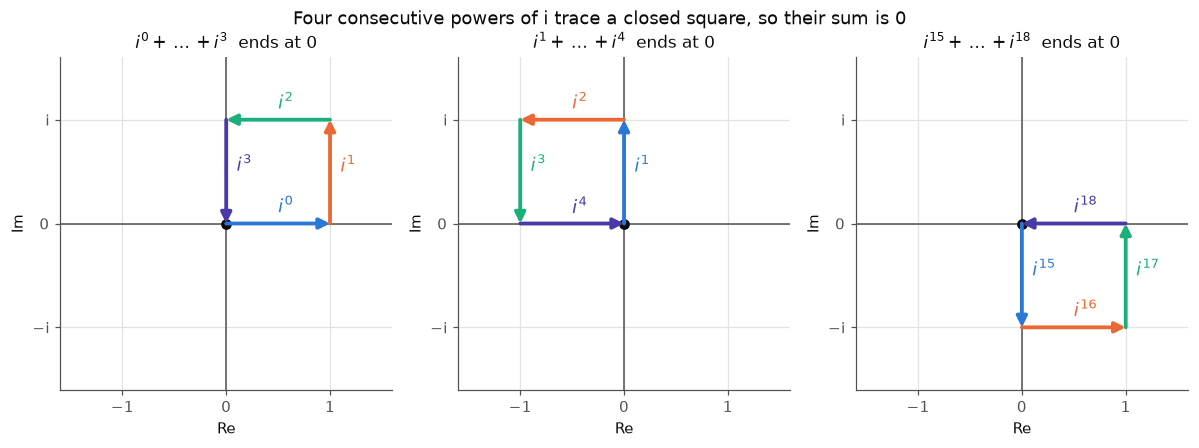

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.9))
for ax, n in zip(axes, [0, 1, 15]):
    argand(ax, lim=1.6); pos = 0j
    for k, c in enumerate([BLUE, ORANGE, AQUA, VIOLET]):
        step = 1j**(n + k)
        arrow(ax, pos, pos + step, c, lw=2.5)
        mid = pos + step/2
        ax.text(mid.real + (0.1 if step.imag else 0), mid.imag + (0.1 if step.real else 0),
                f"$i^{{{n+k}}}$", color=c, fontsize=12)
        pos += step
    ax.plot(0, 0, "o", color=INK, ms=6)
    ax.set_title(f"$i^{{{n}}} + \\dots + i^{{{n+3}}}$  ends at {abs(pos):.0f}", fontsize=11)
fig.suptitle("Four consecutive powers of i trace a closed square, so their sum is 0", fontsize=11.5)
plt.tight_layout(); plt.show()

---
## 6. Questions on Powers of $i$

### Q1. Simplify $\dfrac{i^{592} + i^{590} + i^{588} + i^{586} + i^{584}}{i^{582} + i^{580} + i^{578} + i^{576} + i^{574}}$
Take the **smallest power** out as a common factor, on top and on the bottom:
$$\text{Numerator} = i^{584}\left(i^8 + i^6 + i^4 + i^2 + 1\right), \qquad \text{Denominator} = i^{574}\left(i^8 + i^6 + i^4 + i^2 + 1\right)$$
The brackets are **identical**, so they cancel:
$$\frac{i^{584}}{i^{574}} = i^{10} = i^{8}\cdot i^{2} = 1\cdot(-1) = \boxed{-1}$$

*(In the NCERT version of this question, $1$ is subtracted from the fraction, which gives $-1 - 1 = -2$.)*

> **Trick:** a large power like $i^{584}$ is easy because $584 = 4\cdot146$, so $i^{584} = (i^4)^{146} = 1$. Only the remainder mod 4 matters.

In [9]:
num = sum(1j**k for k in [592, 590, 588, 586, 584])
den = sum(1j**k for k in [582, 580, 578, 576, 574])
print("bracket (i⁸+i⁶+i⁴+i²+1) =", sum(1j**k for k in [8, 6, 4, 2, 0]))
print("ratio =", np.round(num/den, 12), "    ratio − 1 =", np.round(num/den - 1, 12))

bracket (i⁸+i⁶+i⁴+i²+1) = (1+0j)
ratio = (-1-0j)     ratio − 1 = (-2-0j)


### Q2. If $(1 + i)^{200} = x + iy$ with $x, y$ real, find $x$ and $y$.
**Idea:** whatever you do to a complex number, the answer simplifies to the form $x + iy$, so simplify the left side until it looks like that.

Write $200 = 2 \times 100$:
$$(1 + i)^{200} = \left[(1 + i)^2\right]^{100}$$
Use $(a + b)^2 = a^2 + 2ab + b^2$:
$$(1 + i)^2 = 1 + 2i + i^2 = 1 + 2i - 1 = 2i$$
So
$$(1 + i)^{200} = (2i)^{100} = 2^{100}\, i^{100} = 2^{100}\left(i^4\right)^{25} = 2^{100}$$
Comparing $2^{100} + 0\,i = x + iy$:
$$\boxed{x = 2^{100}, \quad y = 0}$$

In [10]:
# Exact check with Python integers: repeatedly multiply (re, im) by (1 + i)
re, im = 1, 0
for _ in range(200):
    re, im = re - im, re + im
print("x == 2**100 :", re == 2**100, "   y =", im)

x == 2**100 : True    y = 0


### Picture *(extra)*: the powers of $1 + i$
Each multiplication by $1 + i$ **turns by $45^\circ$** and **stretches by $\sqrt2$**, because $(1 + i)^2 = 2i$ is a quarter-turn and a doubling. After 8 steps it has turned $360^\circ$ and is back on the positive real axis. $200 = 8 \times 25$, so $(1 + i)^{200}$ also lands on the positive real axis. That is why $y = 0$.

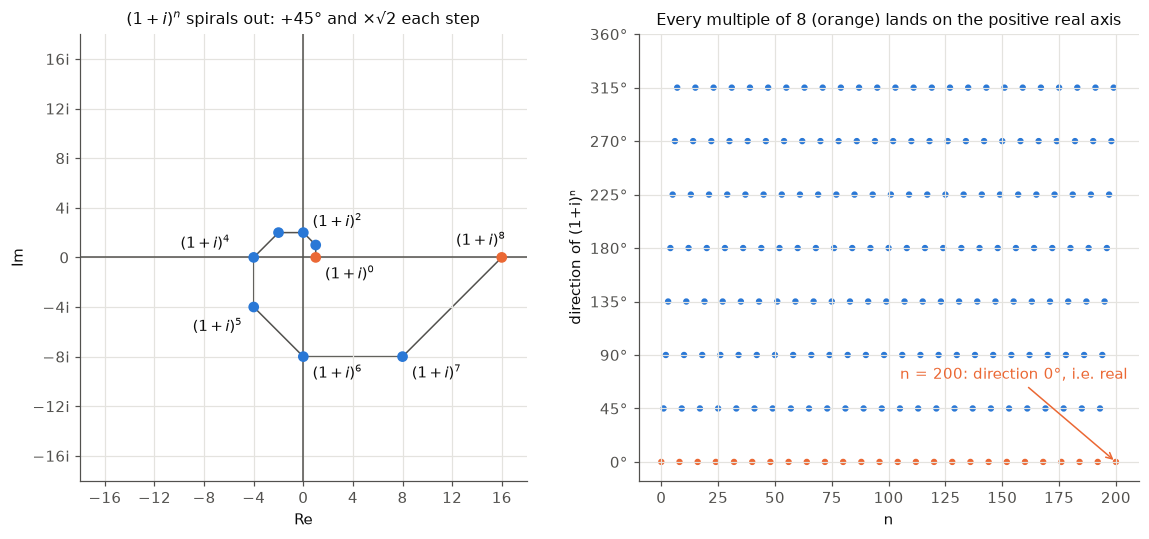

In [11]:
n = np.arange(0, 9)
P = (1 + 1j)**n
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ax = axes[0]; argand(ax, lim=18, ticks=4)
ax.plot(P.real, P.imag, color=INK2, lw=1, zorder=1)
ax.scatter(P.real, P.imag, c=[ORANGE if k % 8 == 0 else BLUE for k in n], s=36, zorder=3)
for k, off in [(0, (6, -14)), (2, (6, 4)), (4, (-48, 6)), (5, (-40, -16)), (6, (6, -14)), (7, (6, -14)), (8, (-30, 8))]:
    ax.annotate(f"$(1+i)^{k}$", (P[k].real, P[k].imag), xytext=off, textcoords="offset points", fontsize=9.5)
ax.set_title("$(1+i)^n$ spirals out: +45° and ×√2 each step", fontsize=10.5)

ax = axes[1]
nn = np.arange(0, 201)
ang = (45*nn) % 360
ax.scatter(nn, ang, s=10, c=[ORANGE if k % 8 == 0 else BLUE for k in nn])
ax.set_yticks(range(0, 361, 45), [f"{a}°" for a in range(0, 361, 45)])
ax.set_xlabel("n"); ax.set_ylabel("direction of (1+i)ⁿ")
ax.annotate("n = 200: direction 0°, i.e. real", (200, 0), xytext=(105, 70), color=ORANGE,
            arrowprops=dict(arrowstyle="->", color=ORANGE))
ax.set_title("Every multiple of 8 (orange) lands on the positive real axis", fontsize=10.5)
plt.tight_layout(); plt.show()

---
## 7. Purely Real, Purely Imaginary, Zero, and Imaginary

Let $z = a + ib$. **Every** $z$ is a complex number. Depending on which part is zero we give it an extra name:

| Condition | Name | Examples |
|---|---|---|
| $\operatorname{Im}(z) = 0$ | **purely real** | $1,\ 2,\ 5,\ -9$ |
| $\operatorname{Re}(z) = 0$ | **purely imaginary** | $i,\ 2i,\ -3i$ |
| $\operatorname{Re}(z) = 0$ **and** $\operatorname{Im}(z) = 0$ | $z = 0$ is **both** purely real and purely imaginary | only $0 + 0i$ |
| $\operatorname{Re}(z) \ne 0$ **and** $\operatorname{Im}(z) \ne 0$ | simply **imaginary** | $3 + 2i,\ -1 - i$ |

> $0$ is the **only** complex number that is both purely real and purely imaginary.

### Picture *(extra)*: where each type lives
Purely real numbers lie on the horizontal axis and purely imaginary numbers on the vertical axis. Zero is where the axes cross, and everything else fills the rest of the plane.

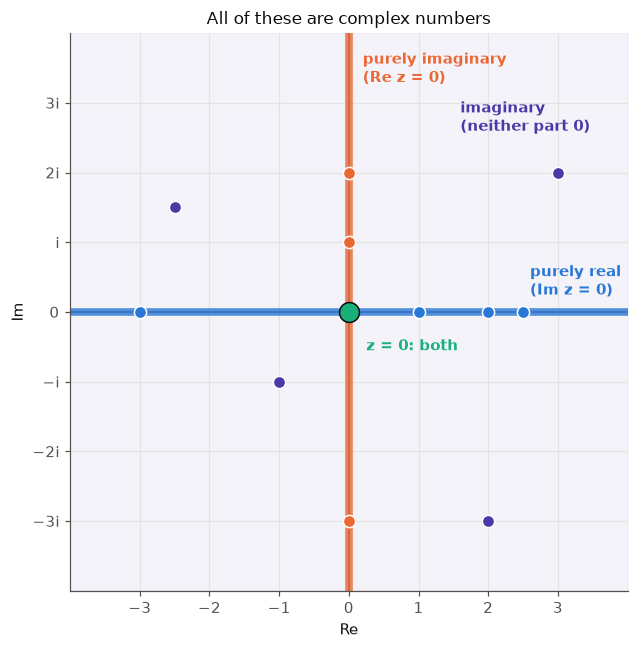

In [12]:
fig, ax = plt.subplots(figsize=(6.4, 6)); argand(ax, lim=4)
ax.fill_between([-4, 4], -4, 4, color=VIOLET, alpha=0.06, zorder=0)
ax.plot([-4, 4], [0, 0], color=BLUE, lw=5, alpha=0.8, zorder=2, solid_capstyle="butt")
ax.plot([0, 0], [-4, 4], color=ORANGE, lw=5, alpha=0.8, zorder=2, solid_capstyle="butt")
ax.plot(0, 0, "o", ms=13, color=AQUA, mec=INK, zorder=4)
for z, c in [(1, BLUE), (2, BLUE), (5/2, BLUE), (-3, BLUE), (1j, ORANGE), (2j, ORANGE), (-3j, ORANGE),
             (3+2j, VIOLET), (-1-1j, VIOLET), (-2.5+1.5j, VIOLET), (2-3j, VIOLET)]:
    z = complex(z); ax.plot(z.real, z.imag, "o", color=c, mec="white", ms=8, zorder=5)
ax.text(2.6, 0.25, "purely real\n(Im z = 0)", color=BLUE, fontsize=10, weight="bold")
ax.text(0.2, 3.3, "purely imaginary\n(Re z = 0)", color=ORANGE, fontsize=10, weight="bold")
ax.text(0.25, -0.55, "z = 0: both", color=AQUA, fontsize=10, weight="bold")
ax.text(1.6, 2.6, "imaginary\n(neither part 0)", color=VIOLET, fontsize=10, weight="bold")
ax.set_title("All of these are complex numbers", fontsize=11)
plt.tight_layout(); plt.show()

---
## 8. Algebra of Complex Numbers

After complex numbers were introduced, people asked: can we add them, subtract them, multiply, divide, take roots, logs, powers and sines? **Yes to all of it.** It works just like real-number algebra, with one extra rule: replace $i^2$ by $-1$.

Let
$$z_1 = a_1 + ib_1, \qquad z_2 = a_2 + ib_2$$

### 8.1 Addition and subtraction: real with real, imaginary with imaginary
$$z_1 + z_2 = (a_1 + a_2) + i\,(b_1 + b_2)$$
$$z_1 - z_2 = (a_1 - a_2) + i\,(b_1 - b_2)$$

### 8.2 Multiplication: expand, then use $i^2 = -1$
$$z_1 z_2 = (a_1 + ib_1)(a_2 + ib_2) = a_1a_2 + i\,a_1b_2 + i\,b_1a_2 + i^2 b_1b_2$$
$$\boxed{z_1 z_2 = (a_1a_2 - b_1b_2) + i\,(a_1b_2 + a_2b_1)}$$

### 8.3 Division: multiply top and bottom by the denominator with the sign of $i$ flipped
This is like **rationalising** a denominator. Multiply numerator and denominator by $a_2 - ib_2$:
$$\frac{z_1}{z_2} = \frac{(a_1 + ib_1)(a_2 - ib_2)}{(a_2 + ib_2)(a_2 - ib_2)}$$
The denominator is $(x + y)(x - y) = x^2 - y^2$ with $y = ib_2$:
$$a_2^2 - i^2 b_2^2 = a_2^2 + b_2^2 \quad\text{(a real number!)}$$
So
$$\boxed{\frac{z_1}{z_2} = \frac{a_1a_2 + b_1b_2}{a_2^2 + b_2^2} + i\,\frac{a_2b_1 - a_1b_2}{a_2^2 + b_2^2}}$$
Again the answer has the form **real + i · real**. That is the beauty of complex numbers.

### 8.4 Multiplying by a scalar (real number) $k$
$$k\,z_1 = k a_1 + i\,k b_1$$

In [13]:
# Check all four formulas against Python's built-in complex arithmetic
a1, b1, a2, b2 = rng.uniform(-5, 5, (4, 100_000))
z1, z2 = a1 + 1j*b1, a2 + 1j*b2
D = a2**2 + b2**2
for name, mine, true in [
    ("z1 + z2", (a1 + a2) + 1j*(b1 + b2), z1 + z2),
    ("z1 − z2", (a1 - a2) + 1j*(b1 - b2), z1 - z2),
    ("z1 · z2", (a1*a2 - b1*b2) + 1j*(a1*b2 + a2*b1), z1*z2),
    ("z1 / z2", (a1*a2 + b1*b2)/D + 1j*(a2*b1 - a1*b2)/D, z1/z2),
]:
    print(f"{name}: formula matches on {np.isclose(mine, true).mean()*100:.2f}% of 100,000 random pairs")

z1, z2 = 3 + 2j, 1 - 1j
print("\nExample: z1 = 3 + 2i, z2 = 1 − i")
print("  z1 + z2 =", z1 + z2, "  z1 − z2 =", z1 - z2, "  z1·z2 =", z1*z2, "  z1/z2 =", z1/z2, "  2·z1 =", 2*z1)

z1 + z2: formula matches on 100.00% of 100,000 random pairs
z1 − z2: formula matches on 100.00% of 100,000 random pairs
z1 · z2: formula matches on 100.00% of 100,000 random pairs
z1 / z2: formula matches on 100.00% of 100,000 random pairs

Example: z1 = 3 + 2i, z2 = 1 − i
  z1 + z2 = (4+1j)   z1 − z2 = (2+3j)   z1·z2 = (5-1j)   z1/z2 = (0.5+2.5j)   2·z1 = (6+4j)


### Pictures *(extra)*: what the operations look like
- **Addition** is "tip to tail", like vectors: the **parallelogram rule**.
- **Multiplication** *rotates and stretches*: the angles add and the lengths multiply. (This is why multiplying by $i$ was a $90^\circ$ turn.)
- **Scalar multiplication** by a real $k$ only stretches, or flips if $k < 0$.

The animation below sweeps $z_2$ around a circle while $z_1$ stays fixed. Watch how $z_1 + z_2$ and $z_1 z_2$ move.

In [14]:
z1 = 1.5 + 0.8j
fig, axes = plt.subplots(1, 2, figsize=(11, 5.4), dpi=72)
for ax in axes: argand(ax, lim=3.2)
th = np.linspace(0, 2*np.pi, 300); r2 = 1.2
for ax in axes: ax.plot(r2*np.cos(th), r2*np.sin(th), color=GRID, lw=1.3, zorder=0)
axes[0].set_title("addition: z₁ + z₂ (parallelogram)", fontsize=10.5)
axes[1].set_title("multiplication: z₁ · z₂ (angles add, lengths multiply)", fontsize=10.5)
mk = lambda ax, c, lw=2.5, ls="-": ax.plot([], [], color=c, lw=lw, ls=ls)[0]
A = dict(z1=mk(axes[0], BLUE), z2=mk(axes[0], ORANGE), s=mk(axes[0], VIOLET, 3),
         p1=mk(axes[0], ORANGE, 1, "--"), p2=mk(axes[0], BLUE, 1, "--"))
B = dict(z1=mk(axes[1], BLUE), z2=mk(axes[1], ORANGE), p=mk(axes[1], AQUA, 3))
path_s, = axes[0].plot([], [], color=VIOLET, lw=1, alpha=0.5)
path_p, = axes[1].plot([], [], color=AQUA, lw=1, alpha=0.5)
txt0 = axes[0].text(-3.0, -2.9, "", fontsize=9.5); txt1 = axes[1].text(-3.0, -2.9, "", fontsize=9.5)
for ax in axes:
    ax.plot([], [], color=BLUE, lw=2.5, label="z₁ = 1.5 + 0.8i"); ax.plot([], [], color=ORANGE, lw=2.5, label="z₂ (|z₂| = 1.2)")
axes[0].plot([], [], color=VIOLET, lw=3, label="z₁ + z₂"); axes[1].plot([], [], color=AQUA, lw=3, label="z₁ · z₂")
for ax in axes: ax.legend(frameon=False, fontsize=8.5, loc="upper left")
seg = lambda line, a, b: line.set_data([a.real, b.real], [a.imag, b.imag])
N = 48; hist = []
def update(f):
    z2 = r2*np.exp(2j*np.pi*f/N); s = z1 + z2; p = z1*z2; hist.append((s, p))
    seg(A["z1"], 0, z1); seg(A["z2"], 0, z2); seg(A["s"], 0, s); seg(A["p1"], z1, s); seg(A["p2"], z2, s)
    seg(B["z1"], 0, z1); seg(B["z2"], 0, z2); seg(B["p"], 0, p)
    H = np.array(hist[-N:]); path_s.set_data(H[:, 0].real, H[:, 0].imag); path_p.set_data(H[:, 1].real, H[:, 1].imag)
    txt0.set_text(f"z₂ = {z2.real:+.2f} {z2.imag:+.2f}i   z₁+z₂ = {s.real:+.2f} {s.imag:+.2f}i")
    txt1.set_text(f"angle(z₁z₂) = {np.degrees(np.angle(z1)):.0f}° + {np.degrees(np.angle(z2)) % 360:.0f}°   "
                  f"|z₁z₂| = {abs(z1):.2f}×{r2}")
    return [*A.values(), *B.values(), path_s, path_p, txt0, txt1]
anim = animation.FuncAnimation(fig, update, frames=N, interval=100, blit=True)
plt.close(fig)
HTML(anim.to_jshtml(default_mode="loop"))

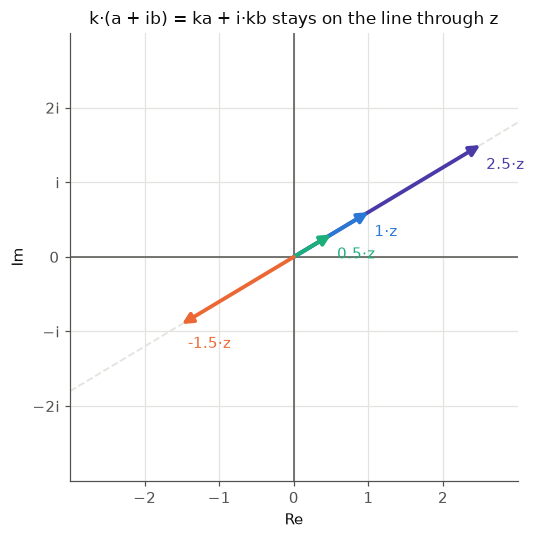

In [15]:
# Scalar multiplication k·z only stretches (k > 0) or flips (k < 0) along the same line
z = 1 + 0.6j
fig, ax = plt.subplots(figsize=(6.2, 5)); argand(ax, lim=3)
ax.plot([-3, 3], [-1.8, 1.8], color=GRID, lw=1.2, ls="--")
for k, c in [(2.5, VIOLET), (1, BLUE), (0.5, AQUA), (-1.5, ORANGE)]:  # longest first so shorter arrows stay visible
    arrow(ax, 0, k*z, c, lw=2.5)
    ax.text((k*z).real + 0.08, (k*z).imag - 0.32, f"{k:g}·z", color=c, fontsize=10)
ax.set_title("k·(a + ib) = ka + i·kb stays on the line through z", fontsize=11)
plt.tight_layout(); plt.show()

---
## 9. Equality of Complex Numbers

Two complex numbers are **equal only when their real parts are equal AND their imaginary parts are equal**:
$$a_1 + ib_1 = a_2 + ib_2 \iff a_1 = a_2 \ \text{ and } \ b_1 = b_2$$
So one complex equation gives **two real equations**. (The next lecture discusses this in detail.)

### Q3. Find real $x$ and $y$ such that $(x^4 + 2xi) - (3x^2 + yi) = (3 - 5i) + (1 + 2yi)$.
**Step 1: write both sides in standard form, real + $i$ · imaginary.** As given they are "messy".
$$\text{LHS} = (x^4 - 3x^2) + i\,(2x - y), \qquad \text{RHS} = 4 + i\,(2y - 5)$$

**Step 2: equate real parts and imaginary parts.**
$$\text{Real:}\quad x^4 - 3x^2 = 4 \qquad\qquad \text{Imaginary:}\quad 2x - y = 2y - 5 \;\Rightarrow\; y = \frac{2x + 5}{3}$$

**Step 3: solve the real equation.** It is a quadratic in $x^2$:
$$x^4 - 3x^2 - 4 = 0 \;\Longrightarrow\; (x^2 - 4)(x^2 + 1) = 0$$
$x$ is **real**, so $x^2 + 1 \ge 1$ can never be $0$. Therefore $x^2 = 4$ and $x = \pm2$.

**Step 4: substitute into $y = \frac{2x + 5}{3}$.**
$$x = 2 \Rightarrow y = \frac{9}{3} = 3, \qquad x = -2 \Rightarrow y = \frac{1}{3}$$
$$\boxed{(x, y) = (2,\ 3)\quad\text{or}\quad(x, y) = \left(-2,\ \tfrac13\right)}$$

x = +2, y = 3.0000:  LHS = 4.0000+1.0000j   RHS = 4.0000+1.0000j   equal: True
x = -2, y = 0.3333:  LHS = 4.0000-4.3333j   RHS = 4.0000-4.3333j   equal: True


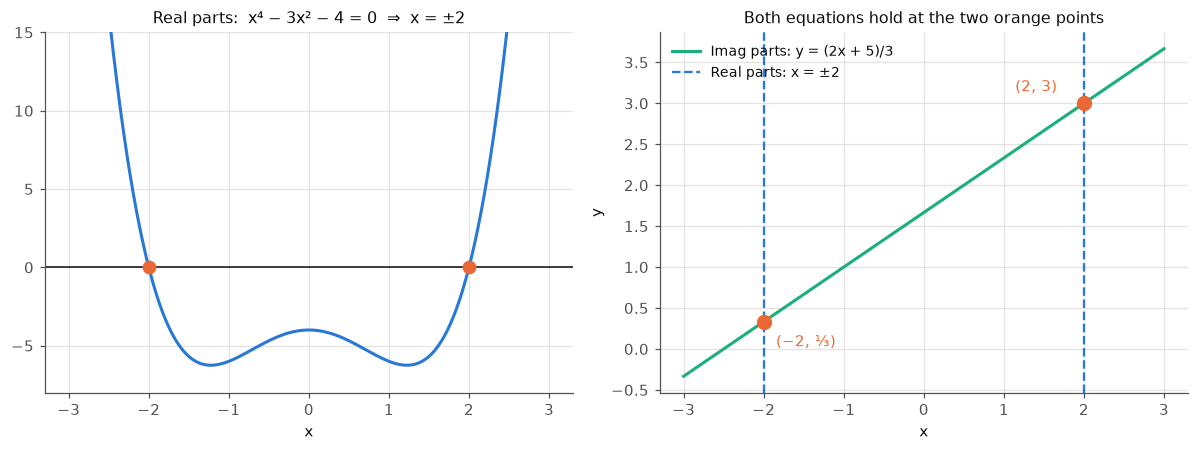

In [16]:
for x, y in [(2, 3), (-2, 1/3)]:
    lhs = (x**4 + 2*x*1j) - (3*x**2 + y*1j); rhs = (3 - 5j) + (1 + 2*y*1j)
    print(f"x = {x:+}, y = {y:.4f}:  LHS = {lhs:.4f}   RHS = {rhs:.4f}   equal: {np.isclose(lhs, rhs)}")

# Picture: each equation is a curve in the (x, y) plane, and the answers are where they cross
xs = np.linspace(-3, 3, 600)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax = axes[0]
ax.plot(xs, xs**4 - 3*xs**2 - 4, color=BLUE, lw=2); ax.axhline(0, color=INK, lw=1)
ax.plot([-2, 2], [0, 0], "o", color=ORANGE, ms=8)
ax.set_ylim(-8, 15); ax.set_xlabel("x"); ax.set_title("Real parts:  x⁴ − 3x² − 4 = 0  ⇒  x = ±2", fontsize=10.5)
ax = axes[1]
ax.plot(xs, (2*xs + 5)/3, color=AQUA, lw=2, label="Imag parts: y = (2x + 5)/3")
for xv in [-2, 2]: ax.axvline(xv, color=BLUE, lw=1.5, ls="--")
ax.plot([], [], color=BLUE, ls="--", label="Real parts: x = ±2")
ax.plot([2, -2], [3, 1/3], "o", color=ORANGE, ms=9, zorder=5)
ax.annotate("(2, 3)", (2, 3), xytext=(-45, 8), textcoords="offset points", color=ORANGE)
ax.annotate("(−2, ⅓)", (-2, 1/3), xytext=(8, -16), textcoords="offset points", color=ORANGE)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.set_title("Both equations hold at the two orange points", fontsize=10.5)
plt.tight_layout(); plt.show()

---
## Summary

| Idea | Result |
|---|---|
| Iota | $i = \sqrt{-1}$ (Euler, 1748), with $i^2 = -1$ |
| Number systems | $\mathbb{N} \subset \mathbb{W} \subset \mathbb{Z} \subset \mathbb{Q} \subset \mathbb{R} \subset \mathbb{C}$ |
| Standard form | $z = a + ib$, $\operatorname{Re}(z) = a$, $\operatorname{Im}(z) = b$ (not $ib$) |
| Powers | $i, -1, -i, 1$ repeating, so $i^n$ depends only on $n \bmod 4$. Also $\frac1i = -i$ |
| Four consecutive powers | $i^n + i^{n+1} + i^{n+2} + i^{n+3} = 0$ |
| Types | purely real ($b = 0$), purely imaginary ($a = 0$), zero (both), imaginary (neither) |
| $+$ and $-$ | real with real, imaginary with imaginary |
| $\times$ | $(a_1a_2 - b_1b_2) + i(a_1b_2 + a_2b_1)$ |
| $\div$ | multiply top and bottom by $a_2 - ib_2$, so the denominator becomes $a_2^2 + b_2^2$ |
| Equality | $a_1 + ib_1 = a_2 + ib_2 \iff a_1 = a_2$ and $b_1 = b_2$ |

**Big takeaway:** no matter what you do to complex numbers, the result simplifies to **real + i · real**.

---
## Practice *(extra)*
1. Find $i^{2026}$, $i^{-35}$, and $i^{97} + i^{98} + i^{99} + i^{100}$.
2. Write $\dfrac{3 + 4i}{1 - 2i}$ in the form $a + ib$.
3. Show that $(1 - i)^{8} = 16$.
4. Find real $x, y$ if $(3x - 2iy) + (2 - 5i) = 8 + i(x - 4)$.

<details>
<summary>Answers (open after attempting)</summary>

1. $2026 = 4\cdot506 + 2$, so $i^{2026} = -1$. $\;-35 = 4\cdot(-9) + 1$, so $i^{-35} = i$. Four consecutive powers add to $0$.
2. Multiply top and bottom by $1 + 2i$: $\dfrac{(3 + 4i)(1 + 2i)}{1 + 4} = \dfrac{3 + 6i + 4i - 8}{5} = -1 + 2i$.
3. $(1 - i)^2 = 1 - 2i - 1 = -2i$, so $(1 - i)^8 = (-2i)^4 = 16\,i^4 = 16$.
4. Real: $3x + 2 = 8 \Rightarrow x = 2$. Imaginary: $-2y - 5 = x - 4 = -2 \Rightarrow y = -\frac32$.
</details>

In [17]:
# Checks for the practice set
print("1:", np.round(1j**2026, 12), np.round(1j**-35, 12), np.round(sum(1j**k for k in range(97, 101)), 12))
print("2:", (3 + 4j)/(1 - 2j))
print("3:", (1 - 1j)**8)
x, y = 2, -1.5
print("4:", (3*x - 2j*y) + (2 - 5j), "==", 8 + 1j*(x - 4))

1: (-1+0j) (-0+1j) 0j
2: (-1+2j)
3: (16+0j)
4: (8-2j) == (8-2j)
